# Linear Regression


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [40]:
data = pd.read_csv("calories.csv")

In [41]:
import pandas as pd

data = pd.read_csv("calories.csv")

print(data.columns)


Index(['User_ID', 'Gender', 'Age', 'Height', 'Weight', 'Duration',
       'Heart_Rate', 'Body_Temp', 'Calories'],
      dtype='object')


In [42]:
data["Gender"] = data["Gender"].str.lower().map({"male": 1, "female": 0})


In [43]:
X = data.drop("Calories", axis=1)
y = data["Calories"]

In [44]:
X = data.drop(["User_ID", "Calories"], axis=1)


In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [46]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [47]:
y_pred_linear = model.predict(X_test)

In [48]:
print("MAE:", mean_absolute_error(y_test, y_pred_linear))
print("MSE:", mean_squared_error(y_test, y_pred_linear))

MAE: 8.441513553849697
MSE: 131.9957457508168


In [49]:
from sklearn.metrics import r2_score

accuracy = r2_score(y_test, y_pred_linear)
print("Model Accuracy(R2 score):", accuracy)


Model Accuracy(R2 score): 0.9672937151257296


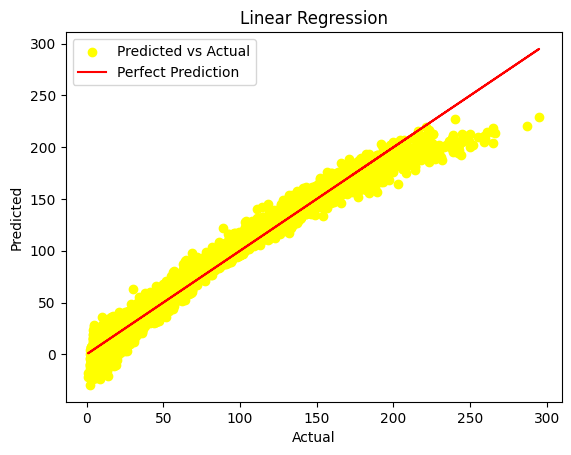

In [50]:
plt.scatter(y_test, y_pred_linear, color=['yellow'], label='Predicted vs Actual')

plt.plot(y_test,y_test, color='red',  label='Perfect Prediction')

plt.title('Linear Regression')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
plt.show()

In [51]:
# Toydataset example


sample_input = np.array([[1, 25, 175, 70, 30, 120, 38]])

prediction = model.predict(sample_input)
print("Calories Burned:", prediction[0])


Calories Burned: 257.3063634600157


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Polynomial Regression

In [52]:
from sklearn.preprocessing import PolynomialFeatures

In [53]:
poly = PolynomialFeatures(degree=3)

X_poly = poly.fit_transform(X)
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_poly, y, test_size=0.2, random_state=42)

polymodel = LinearRegression()

polymodel.fit(X_train_p,y_train_p)


y_pred_poly = polymodel.predict(X_test_p)

In [54]:
print("MAE:", mean_absolute_error(y_test, y_pred_poly))
print("MSE:", mean_squared_error(y_test, y_pred_poly))

MAE: 0.254154203940508
MSE: 0.08599916855505582


In [55]:
from sklearn.metrics import r2_score

accuracy = r2_score(y_test, y_pred_poly)
print("Model Accuracy(R2 score):", accuracy)

Model Accuracy(R2 score): 0.9999786908790907


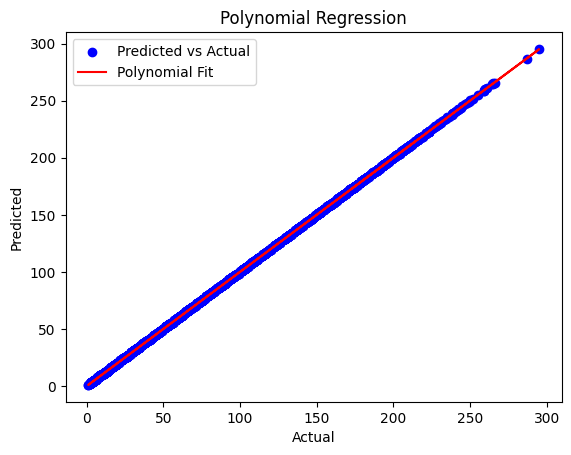

In [56]:
plt.scatter(y_test, y_pred_poly, color=['blue'], label='Predicted vs Actual')

plt.plot(y_test,y_test, color='red',  label='Polynomial Fit')

plt.title('Polynomial Regression')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
plt.show()

In [57]:
# Toydataset example

# Define a single sample with the original 7 features as a 2D array
sample_original_features = np.array([[1, 25, 175, 70, 30, 120, 38]])

# Apply the same polynomial transformation that was used for training
sample_poly_transformed = poly.transform(sample_original_features)

prediction = polymodel.predict(sample_poly_transformed)
print("Calories Burned:", prediction[0])

Calories Burned: 229.6183201307706


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


# Comparison

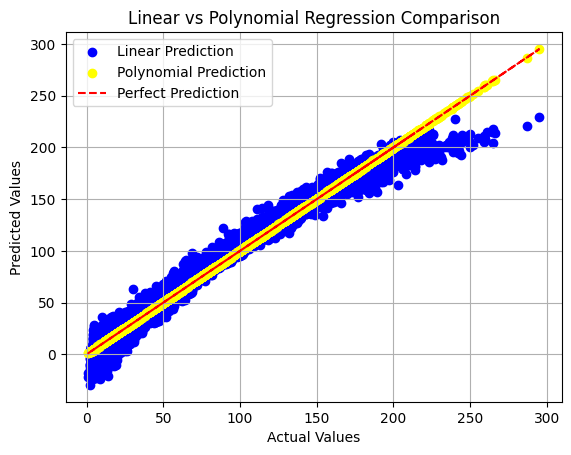

In [58]:
import matplotlib.pyplot as plt


# Linear Regression points
plt.scatter(y_test, y_pred_linear, color='blue', label='Linear Prediction')

# Polynomial Regression points
plt.scatter(y_test, y_pred_poly, color='yellow', label='Polynomial Prediction')

# Perfect line (y = x)
plt.plot(y_test, y_test, color='red', linestyle='--', label='Perfect Prediction')

plt.title('Linear vs Polynomial Regression Comparison')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True)

plt.show()